In [2]:
# Project: Slip severity and pre-slip area exploration
# Author: Sam Brown
# Description: Exploring methods to calculate and compare pre-slip and slip tendencies
# Date: 2025-02-26


# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, filtfilt
from scipy.integrate import simps
import scipy.signal



# Set path to event files
evts_path = "/Users/sambrown04/Documents/SURF/Events/2010_2010Events2stas" 

In [4]:
def plot_event(event: pd.DataFrame, var="x") -> None:
    """
    Plot

    Parameters
    ----------
    event : pd.DataFrame
        Event to plot
    var : str
        Variable to plot.
        Valid options: 'x', 'y', 'z'
    """

    fig, ax1 = plt.subplots(figsize=(8, 6))
    times = pd.to_datetime(event["time"])
    sta_name_len = 4  # Length of station name for title
    plot_cols = [col for col in event if str(col).endswith(var)]

    first = True
    # Loop through stations for plotting
    for plot_col in plot_cols:
        demeaned_to_0 = (event[plot_col] - np.mean(event[plot_col])) - (
            event[plot_col][event.index[0]] - np.mean(event[plot_col])
        )
        if not np.isnan(event[plot_col][event.index[0]]):
            if first:
                ax2_dummy = demeaned_to_0
                first = False
            ax1.plot(times, demeaned_to_0, label=str(plot_col)[:sta_name_len])
    ax1.set_ylabel(f"{var.upper()} Displacement [meters]")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax1.legend()
    ax1.set_xlim(times.iloc[0], times.iloc[-1])

    # Setup dates using second axis
    ax2 = ax1.twiny()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    fig.subplots_adjust(bottom=0.10)
    ax2.set_frame_on(True)
    ax2.patch.set_visible(False)
    ax2.xaxis.set_ticks_position("bottom")
    ax2.xaxis.set_label_position("bottom")
    ax2.spines["bottom"].set_position(("outward", 20))
    ax2.set_xlabel("DateTime")

    # Need to plot something on ax2 to get the correct dates
    ax2.plot(times, ax2_dummy)
    for label in ax2.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)

In [6]:
# storing events in data frame for use
events_list = [] # list of pandas dataframes

for evt_path in os.listdir(evts_path): # loop over each file name in directory
    full_path = os.path.join(evts_path, evt_path) # joins directory path and file name
    print(f"Loading {evt_path}") 
    event = pd.read_csv(full_path, sep="\t") # load in
        
    events_list.append(event)

Loading 2010-11-18_23-03-00.evt
Loading 2010-08-09_01-24-45.evt
Loading 2010-03-13_00-28-30.evt
Loading 2010-02-18_08-46-45.evt
Loading 2010-06-24_08-31-00.evt
Loading 2010-06-17_14-04-45.evt
Loading 2010-09-20_20-30-30.evt
Loading 2010-09-04_22-31-30.evt
Loading 2010-05-06_21-24-45.evt
Loading 2010-02-22_19-26-45.evt
Loading 2010-07-15_12-19-45.evt
Loading 2010-06-01_04-24-45.evt
Loading 2010-12-14_11-10-00.evt
Loading 2010-11-07_14-18-00.evt
Loading 2010-12-04_21-10-00.evt
Loading 2010-10-06_06-29-45.evt
Loading 2010-03-14_21-05-00.evt
Loading 2010-10-29_18-28-00.evt
Loading 2010-01-20_14-16-45.evt
Loading 2010-06-25_01-09-45.evt
Loading 2010-09-22_10-24-45.evt
Loading 2010-04-03_05-07-00.evt
Loading 2010-06-17_04-19-45.evt
Loading 2010-02-01_10-46-45.evt
Loading 2010-07-23_10-00-30.evt
Loading 2010-03-09_18-10-00.evt
Loading 2010-03-26_19-01-45.evt
Loading 2010-05-17_04-04-45.evt
Loading 2010-01-15_15-30-00.evt
Loading 2010-01-11_20-34-45.evt
Loading 2010-11-06_23-33-00.evt
Loading 

In [7]:
# dataframe that has x values in terms of total displacement
def preprocess_events(raw_events, var='x'):
    """
    Preprocess a list of event DataFrames by aligning and cleaning displacement data.

    Parameters
    ----------
    raw_events : list of pandas.DataFrame
        raw data uploaded into events_list in this case
    var : str, optional
        which axis you want to focus on (x,y,z)

    Returns
    -------
    list of pandas.DataFrame
        A list of cleaned DataFrames where:
        - 'time_sec' gives time in seconds from the start of each event.
        - Only columns ending in `var` and 'time_sec' are retained.
        - Calculate displacement relative to the start of the event
    """
    
    processed_events = [] 

    # loop through full raw data
    for event in raw_events:
        # make copy to not worry about editing raw data
        event_clean = event.copy()

        # parse time and calculate seconds from first timestamp (to_datetime and dt.total_seconds)
        event_clean['time_dt'] = pd.to_datetime(event_clean['time'])
        event_clean['time_sec'] = (event_clean['time_dt'] - event_clean['time_dt'].iloc[0]).dt.total_seconds()

        # Keep only columns ending with `var` 
        var_cols = [col for col in event_clean.columns if col.endswith(var)]
        event_clean = event_clean[var_cols + ['time_sec']]  # Keep only var cols and time_sec

        # Drop any remaining NaN columns
        event_clean = event_clean.dropna(axis=1)

        # Recalculate displacement relative to first row for each column
        for col in var_cols: # loop over columns
            if col in event_clean.columns: 
                event_clean[col] = abs(event_clean[col] - event_clean[col].iloc[0])

        processed_events.append(event_clean)

    return processed_events

In [8]:
# test
cleanlist = preprocess_events(events_list)
cleanlist[5].head(15)

,la02x,la05x,la07x,la09x,time_sec
0,0.000000,0.000000,0.000000,0.000000,0.0
1,0.007026,0.006873,0.011875,0.001335,15.0
2,0.014854,0.010817,0.017877,0.000264,30.0
3,0.007867,0.001196,0.006981,0.001863,45.0
4,0.005478,0.004675,0.002140,0.002520,60.0
5,0.004535,0.001791,0.010996,0.003177,75.0
6,0.013303,0.006025,0.011603,0.004800,90.0
7,0.011059,0.000253,0.010432,0.006423,105.0
8,0.007791,0.005003,0.007500,0.006399,120.0
9,0.011422,0.001866,0.007614,0.006375,135.0


In [9]:
# derivative function

def derivative(x_col, order=4, crit=.05, spacing=15):
    """
    x_col - col of x values to take derivative of
    order - butterworth filter order
    crit - critical value of butterworth filter
    spacing - spacing of gradient
    """

    y = x_col - np.mean(x_col)

    #1st deriv
    b, a = scipy.signal.butter(order, crit) # butterworth filter 
    filtered = scipy.signal.filtfilt(b, a, y, padlen=50) # applies filter, no phase shift
    grad = np.gradient(filtered, spacing) # computes gradient
    return grad


In [10]:
# Initialize pandas dataframe that will store each events and the new features
# list of pandas data frames, columns are pre-slip area and severity of slippage, rows are the different stations for the event
new_features = []

columns = ["station", "pre-slip_area", "slip_severity", "peak_time"]

# One empty DataFrame per event
for _ in events_list:
    new_features.append(pd.DataFrame(columns=columns))

In [11]:
# preprocessed events (only time from start of event and the stations displacement for specified var = x , y, or z
pre_events = preprocess_events(events_list, var='x')

# loop over events
for i, event in enumerate(pre_events):
    # intialize new dataframe
    event_features = pd.DataFrame(columns=columns)

    # Get a list of all station columns excluding the tim_sec column
    cols = [col for col in event.columns if col != 'time_sec']

    # loop over column (stations)
    for col in cols:

        # calculate first and second derivatives
        grad = derivative(event[col].values)
        grad2 = derivative(grad)

        # index for max 2nd deriv
        max_idx = np.argmax(np.abs(grad2))

        #corresponding time
        max_time = event['time_sec'].iloc[max_idx]

        # Compute severity (magnitude of 2nd derivative at peak)
        severity = np.abs(grad2[max_idx])

        # Now we will calculate the magnitude of "pre-slip" using an integral and trapezoid rule
        
        # Find the index of the time value closest to the max time (15 sec)
        closest_idx = (np.abs(event['time_sec'] - max_time)).idxmin()

        # extract time and displacement values up until that index
        x_segment = event['time_sec'].iloc[:closest_idx + 1].values
        y_segment = event[col].iloc[:closest_idx + 1].values

        # now find value of integral from start till max time
        integral = np.trapz(y_segment, x_segment)
        
        print(f"Adding row for station: {col}, area: {integral}, severity: {severity}")
        event_features.loc[len(event_features)] = {
            "station": col,
            "pre-slip_area": float(integral),
            "slip_severity": severity,
            "peak_time": max_time
        }
    
    new_features[i] = (event_features)
        

        



Adding row for station: la01x, area: 86.12088494570344, severity: 6.613399823334758e-07
Adding row for station: la02x, area: 78.14622818055796, severity: 5.853300905042365e-07
Adding row for station: la04x, area: 140.10030748395366, severity: 6.513986516957838e-07
Adding row for station: la05x, area: 89.82689980737632, severity: 3.453580597617916e-07
Adding row for station: la06x, area: 72.67626888133236, severity: 9.57190652007794e-07
Adding row for station: la07x, area: 74.0171179491881, severity: 6.688351953269138e-07
Adding row for station: la08x, area: 96.08842022673343, severity: 2.1253941477552525e-07
Adding row for station: la09x, area: 699.6720078730141, severity: 2.1111229295707186e-07
Adding row for station: la10x, area: 58.78627775775385, severity: 7.31483891875185e-07
Adding row for station: la02x, area: 110.44287354976404, severity: 1.4456041878269555e-06
Adding row for station: la09x, area: 2.1737071925599594, severity: 2.695754446496851e-07
Adding row for station: la01x

In [12]:
new_features[70].head(11)


,station,pre-slip_area,slip_severity,peak_time
0,la01x,88.517819,1.168689e-06,6465.0
1,la02x,98.353925,1.139633e-06,6510.0
2,la04x,67.533365,1.059353e-06,6495.0
3,la05x,115.591824,5.570749e-07,6420.0
4,la06x,99.374265,1.383720e-06,6465.0
5,la07x,112.559847,1.123859e-06,6405.0
6,la08x,188.130960,2.221970e-07,6585.0
7,la09x,11.445799,1.972082e-07,1935.0
8,la10x,79.656139,1.315481e-06,6405.0


In [13]:
# Find largest and smallest area under curve

# define starting variables for min max
max_total_area = -float('inf')
min_total_area = float('inf')
max_range = -float('inf')

event_max_area = None
event_min_area = None
event_max_range = None

for i, event in enumerate(new_features): # loop through each event 
    total_area = event['pre-slip_area'].sum()
    range_area = event['pre-slip_area'].max() - event['pre-slip_area'].min() # difference of "pre-slip" area

    if total_area > max_total_area:
        max_total_area = total_area
        event_max_area = i

    if total_area < min_total_area:
        min_total_area = total_area
        event_min_area = i

    if range_area > max_range:
        max_range = range_area
        event_max_range = i

print(f"Event with largest pre-slip area: Event {event_max_area} (Total: {max_total_area})")
print(f"Event with smallest pre-slip area: Event {event_min_area} (Total: {min_total_area})")
print(f"Event with largest gap in pre-slip area: Event {event_max_range} (Gap: {max_range})")

Event with largest pre-slip area: Event 252 (Total: 6238.550435003126)
Event with smallest pre-slip area: Event 418 (Total: 4.503547283238731)
Event with largest gap in pre-slip area: Event 475 (Gap: 1778.2804904700606)


In [14]:
all_pre_slip_areas = pd.concat([event['pre-slip_area'] for event in new_features]) # Put all pre slip areas in one dataset

summary_stats = all_pre_slip_areas.describe()
print(summary_stats)

count    3695.000000
mean      137.590025
std       164.807346
min         0.000000
25%        78.785687
50%       107.253754
75%       135.120722
max      1833.968414
Name: pre-slip_area, dtype: float64


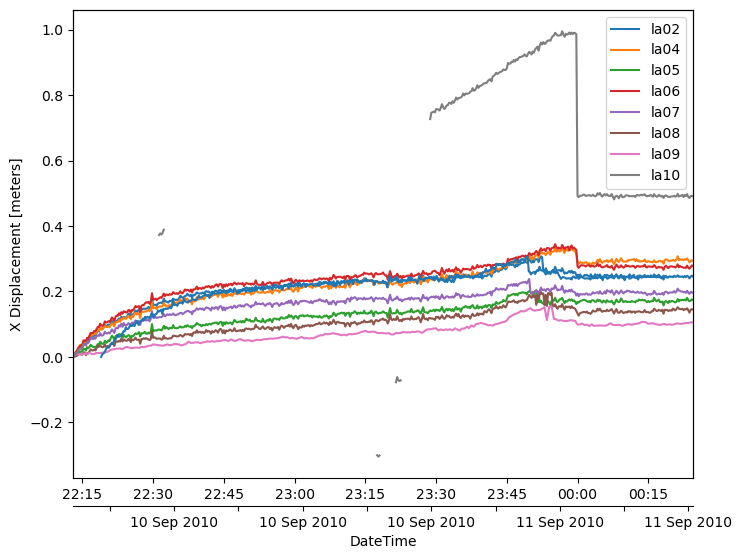

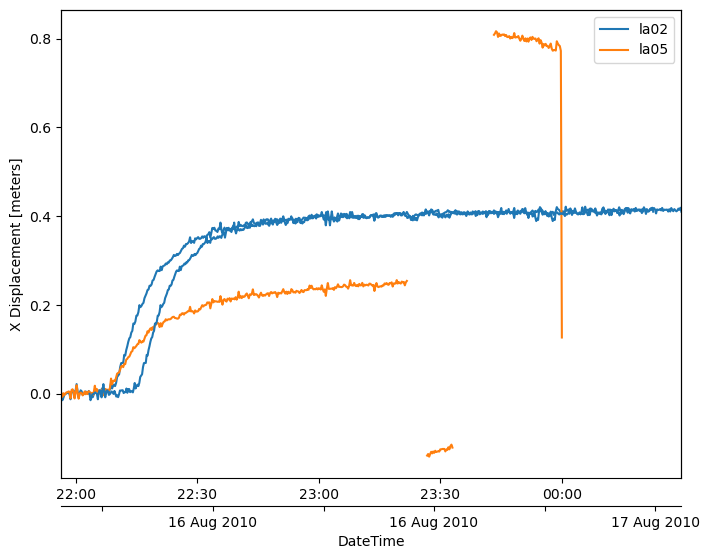

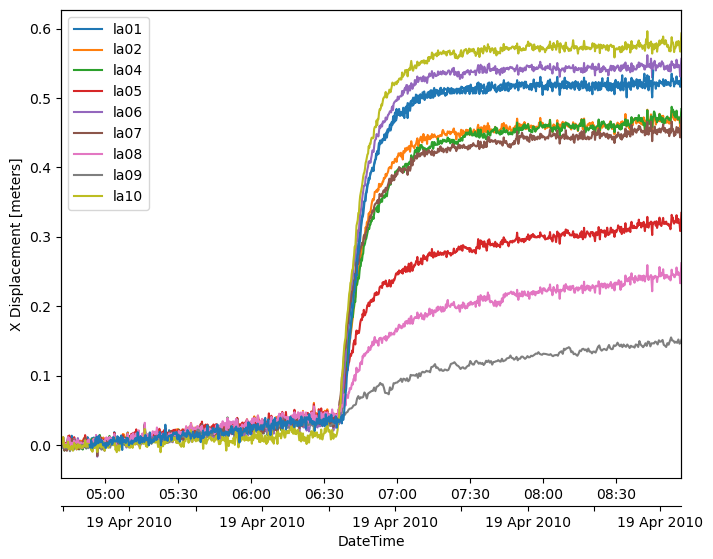

In [15]:
plot_event(events_list[252], var = 'x')
plot_event(events_list[418], var = 'x')
plot_event(events_list[475], var = 'x')

In [16]:
# find events with "sharpest" slip
avg_list = []

#Calculate average 2nd derivs for each event
for i, event in enumerate(new_features):
    average_sharp = event['slip_severity'].mean()
    avg_list.append(average_sharp)
    
max_value = max(avg_list)
max_index = avg_list.index(max_value)

min_value = min(avg_list)
min_index = avg_list.index(min_value)

print(f'The sharpest break is event {max_index} and it is {max_index}')
print(f'The most gradual break is event {min_index} and it is {min_value}')


The sharpest break is event 345 and it is 345
The most gradual break is event 24 and it is 2.2385981562673025e-07


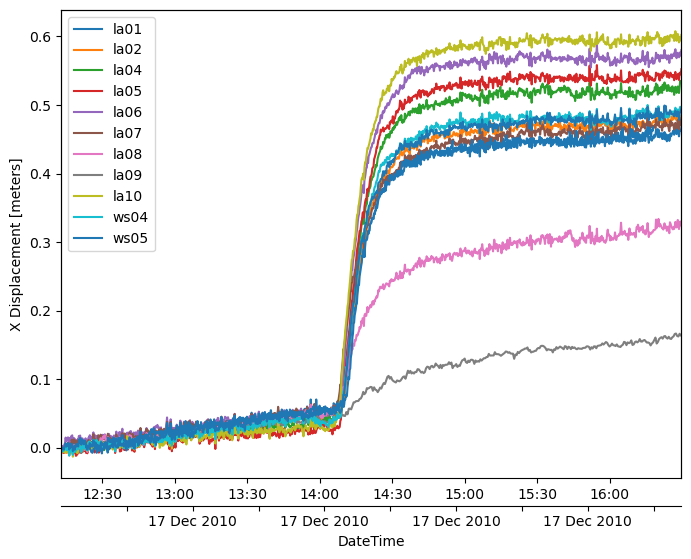

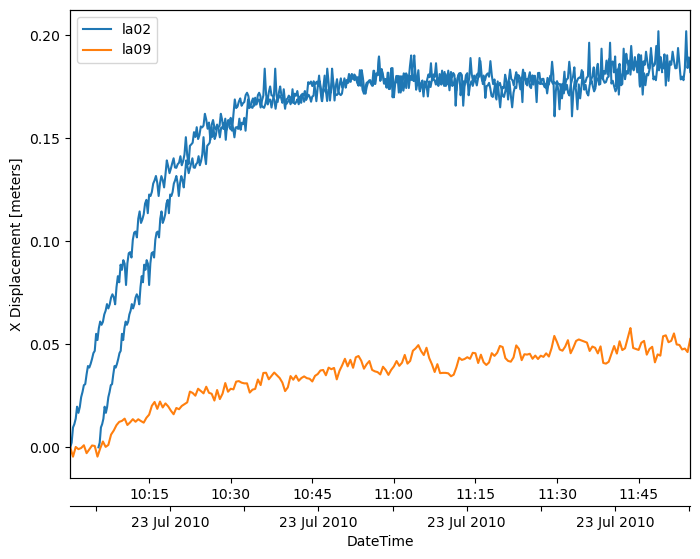

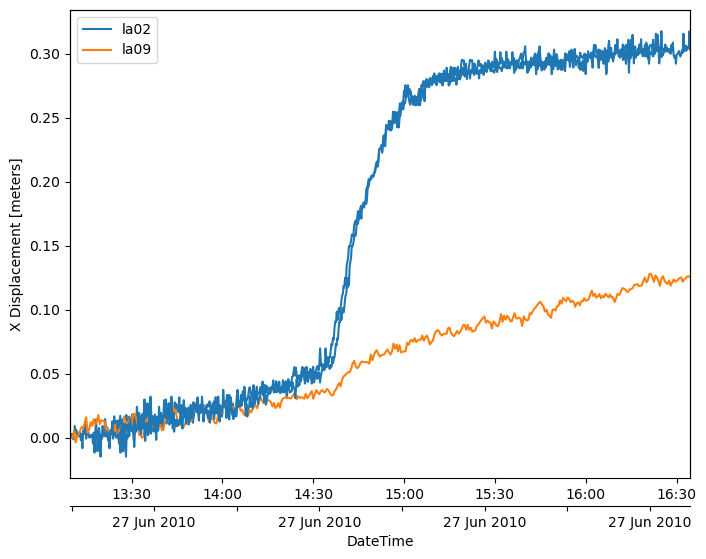

In [17]:
plot_event(events_list[345], var = 'x')
plot_event(events_list[24], var = 'x')
plot_event(events_list[401], var = 'x')

In [18]:
# see if there is a correlation between pre-slippage and severity of slip.
all_pre_slip = pd.concat([df['pre-slip_area'] for df in new_features], ignore_index=True)
all_slip_sev = pd.concat([df['slip_severity'] for df in new_features], ignore_index=True)

result = pd.DataFrame({
    'pres-slip': all_pre_slip,
    'slip-severity': all_slip_sev
})

result

,pres-slip,slip-severity
0,86.120885,6.613400e-07
1,78.146228,5.853301e-07
2,140.100307,6.513987e-07
3,89.826900,3.453581e-07
4,72.676269,9.571907e-07
...,...,...
3690,105.567175,7.391463e-07
3691,100.793511,5.457559e-07
3692,151.882970,2.850382e-07
3693,30.578310,2.260444e-07


Text(0, 0.5, 'Slip Severity (2nd deriv)')

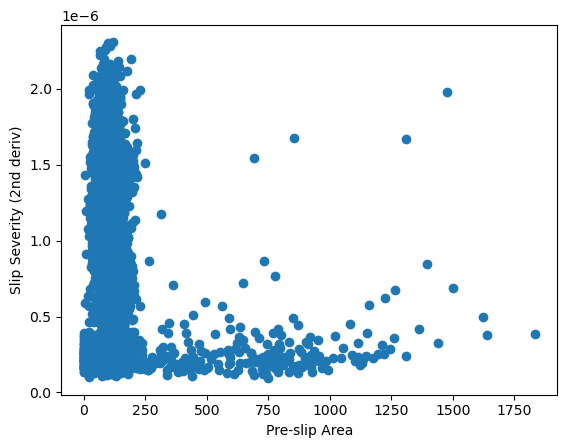

In [35]:
plt.scatter(result['pres-slip'], result['slip-severity'])
plt.xlabel('Pre-slip Area')
plt.ylabel('Slip Severity (2nd deriv)')

It appears that large pre-slip area does not correspond with a large slip severity (all the high pre-slip area points are low on the slip-severity axis).